## Dataset 

In this homework, we'll build a model for classifying various hair types. For this, we will use the Hair Type dataset that was obtained from Kaggle and slightly rebuilt.

In [10]:
import numpy as np
import torch
from PIL import Image

In [ ]:
! wget https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip
!unzip data.zip -d data

--2026-04-11 17:37:11--  https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/405934815/e712cf72-f851-44e0-9c05-e711624af985?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-11T18%3A12%3A09Z&rscd=attachment%3B+filename%3Ddata.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-11T17%3A11%3A15Z&ske=2026-04-11T18%3A12%3A09Z&sks=b&skv=2018-11-09&sig=0C8Zwyyd%2BgdTltpamwczGbG4RlW28yAtib%2BCltRLp08%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NTkzMDgzMSwibmJmIjoxNzc1OTI5MDMxLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdG

### Reproducibility

Reproducibility in deep learning is a multifaceted challenge that requires attention to both software and hardware details. In some cases, we can't guarantee exactly the same results during the same experiment runs.

Therefore, in this homework we suggest to set the random number seed generators by:

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
try:
    import google.colab
    print("Running on Colab")
except Exception:
    print("Not Colab")

Running on Colab


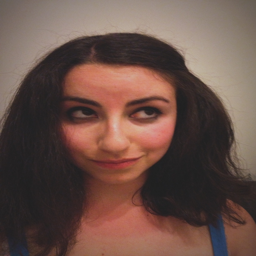

In [15]:
img = Image.open('data/data/train/straight/vsco_063013_3.jpg')
img.resize((256, 256))

In [18]:
X = np.array(img.resize((224, 224)))
X.shape

(224, 224, 3)

### Define dataset class

In [41]:
import os
from torch.utils.data import Dataset
# This declares your custom dataset class, inheriting from
# torch.utils.data.Dataset.
class HairDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [42]:
import torch.nn as nn

class HairtypeClassifier(nn.Module):
    def __init__(self):

        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=(3,3), stride=1, padding=0)
        self.relu = nn.ReLU()
        self.max_pooling = nn.MaxPool2d((2, 2))
        self.flatten = nn.Flatten()
        # compute flattened size: (200-2)=198 -> after pool -> 99
        flat_size = 32 * 99 * 99
        self.linear = nn.Linear(flat_size, 64)
        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.max_pooling(x)
        x = self.flatten(x)
        x = self.linear(x)
        x = self.relu(x)
        logits = self.output_layer(x)
        # probs = torch.sigmoid(logits).squeeze(1)
        return logits

In [43]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [44]:
def make_model(
        learning_rate=0.002,
        momentum=0.8
):
    model = HairtypeClassifier()
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
    return model, optimizer

In [45]:
model, optimizer = make_model()

In [46]:

from torchsummary import summary

summary(model, input_size=(3, 200, 200))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 198, 198]             896
              ReLU-2         [-1, 32, 198, 198]               0
         MaxPool2d-3           [-1, 32, 99, 99]               0
           Flatten-4               [-1, 313632]               0
            Linear-5                   [-1, 64]      20,072,512
              ReLU-6                   [-1, 64]               0
            Linear-7                    [-1, 1]              65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.46
Forward/backward pass size (MB): 23.93
Params size (MB): 76.57
Estimated Total Size (MB): 100.96
----------------------------------------------------------------


In [47]:
# Option 2: Manual counting
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 20073473


### Generators and Training

For the next two questions, use the following transformation for both train and test sets:

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

test_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

In [ ]:
from torch.utils.data import DataLoader

train_dataset = HairDataset(
    data_dir='data/data/train/',
    transform=train_transforms
)

test_dataset = HairDataset(
    data_dir='data/data/test/',
    transform=test_transforms
)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

In [ ]:
def train_and_evaluate(model, optimizer, train_loader, test_loader, num_epochs):

    history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = correct_train / total_train
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels = labels.float().unsqueeze(1)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_epoch_loss = val_running_loss / len(test_dataset)
        val_epoch_acc = correct_val / total_val
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, "
            f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
            f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

In [63]:
train_and_evaluate(model, optimizer, train_loader, test_loader, num_epochs = 10)

Epoch 1/10, Loss: 0.6429, Acc: 0.6230, Val Loss: 0.6603, Val Acc: 0.5970
Epoch 2/10, Loss: 0.6152, Acc: 0.6429, Val Loss: 0.6096, Val Acc: 0.6567
Epoch 3/10, Loss: 0.6162, Acc: 0.6629, Val Loss: 0.6343, Val Acc: 0.6119
Epoch 4/10, Loss: 0.6248, Acc: 0.6604, Val Loss: 0.6333, Val Acc: 0.6368
Epoch 5/10, Loss: 0.6075, Acc: 0.6829, Val Loss: 0.6183, Val Acc: 0.6368
Epoch 6/10, Loss: 0.6107, Acc: 0.6679, Val Loss: 0.6284, Val Acc: 0.6318
Epoch 7/10, Loss: 0.5965, Acc: 0.6742, Val Loss: 0.5973, Val Acc: 0.6766
Epoch 8/10, Loss: 0.6068, Acc: 0.6617, Val Loss: 0.6136, Val Acc: 0.6567
Epoch 9/10, Loss: 0.6023, Acc: 0.6692, Val Loss: 0.6191, Val Acc: 0.6667
Epoch 10/10, Loss: 0.5990, Acc: 0.6754, Val Loss: 0.6161, Val Acc: 0.6716


In [65]:
np.median(history['acc'])

np.float64(0.7328339575530587)

### Data Augmentation

For the next two questions, we'll generate more data using data augmentations.

Add the following augmentations to your training data generator:

- transforms.RandomRotation(50),
- transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
- transforms.RandomHorizontalFlip(),

In [66]:
def dataset_prep():

    train_transforms = transforms.Compose([
        transforms.Resize((200, 200)),
        transforms.RandomRotation(50),
        transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ) # ImageNet normalization
    ])

    test_transforms = transforms.Compose([
        transforms.Resize((200, 200)),
        transforms.RandomRotation(50),
        transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ) # ImageNet normalization
    ])

    from torch.utils.data import DataLoader

    train_dataset = HairDataset(
        data_dir='data/data/train/',
        transform=train_transforms
    )

    test_dataset = HairDataset(
        data_dir='data/data/test/',
        transform=test_transforms
    )

    train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, test_loader

In [67]:
train_loader, test_loader = dataset_prep()

In [68]:
train_and_evaluate(model, optimizer, train_loader, test_loader, num_epochs = 10)

Epoch 1/10, Loss: 0.5847, Acc: 0.6916, Val Loss: 0.6573, Val Acc: 0.6020
Epoch 2/10, Loss: 0.6048, Acc: 0.6604, Val Loss: 0.5974, Val Acc: 0.6866
Epoch 3/10, Loss: 0.5864, Acc: 0.6866, Val Loss: 0.6261, Val Acc: 0.6517
Epoch 4/10, Loss: 0.6016, Acc: 0.6754, Val Loss: 0.6116, Val Acc: 0.6418
Epoch 5/10, Loss: 0.5973, Acc: 0.6816, Val Loss: 0.6428, Val Acc: 0.6119
Epoch 6/10, Loss: 0.5803, Acc: 0.6841, Val Loss: 0.6508, Val Acc: 0.6119
Epoch 7/10, Loss: 0.5859, Acc: 0.6692, Val Loss: 0.6077, Val Acc: 0.6517
Epoch 8/10, Loss: 0.5831, Acc: 0.6904, Val Loss: 0.6082, Val Acc: 0.6766
Epoch 9/10, Loss: 0.5910, Acc: 0.6816, Val Loss: 0.6097, Val Acc: 0.6667
Epoch 10/10, Loss: 0.5621, Acc: 0.6929, Val Loss: 0.6369, Val Acc: 0.6517
